# 02 · Job postings: software development vs. other occupations (Indeed)

**Question.** After ChatGPT's release, did software-development job postings fall *relative to other occupations*? And did that fall start before the release?

**Data.** Indeed Hiring Lab job-postings indices (daily, seasonally adjusted, 1 Feb 2020 = 100) for 47 occupational categories plus all postings, retrieved from FRED. Also Eloundou et al. (2024) GPT-exposure scores, mapped to Indeed categories through a documented SOC crosswalk (section 5).

**Design.**
1. Descriptive timing: peak, level at release, latest level.
2. Two-way fixed-effects difference-in-differences on an occupation × month panel. Software is the only treated unit, so inference comes from **placebo permutation**: the same regression is re-run treating each other occupation as if it were software.
3. Quarterly event study relative to 2022Q3, with the placebo distribution as the band.
4. Placebo-in-time test: a fake "treatment" in March 2022, when the Fed began raising rates.
5. Cross-occupation relationship between GPT exposure and the post-release change in postings.

**Limits.** The Indeed indices count postings, not hires, and **do not break postings down by seniority**. On their own they cannot show a *junior* penalty.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from common import *
set_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

from fetch_data import INDEED_SERIES

In [2]:
raw = pd.concat({name: load_fred(sid) for sid, name in INDEED_SERIES.items()}, axis=1, sort=True)
print(raw.shape, raw.index.min().date(), "->", raw.index.max().date())
ends = raw.apply(lambda s: s.last_valid_index())
print("Series that end early:")
print(ends[ends < raw.index.max()].dt.date.to_string())

(2408, 48) 2020-02-01 -> 2026-09-04
Series that end early:
IT Operations & Helpdesk              2025-07-18
Mathematics                           2025-07-18
Information Design & Documentation    2025-07-18
Veterinary                            2026-02-27
Beauty & Wellness                     2025-09-05
Sports                                2026-03-20


## 1. Timing of the software-postings decline

Software postings peak:      233.8 on 2022-02-28
At ChatGPT release:          142.5 on 2022-11-30
Latest:                       76.1 on 2026-09-04
All postings latest:         102.4
Share of the peak-to-latest decline that happened BEFORE the release: 58%


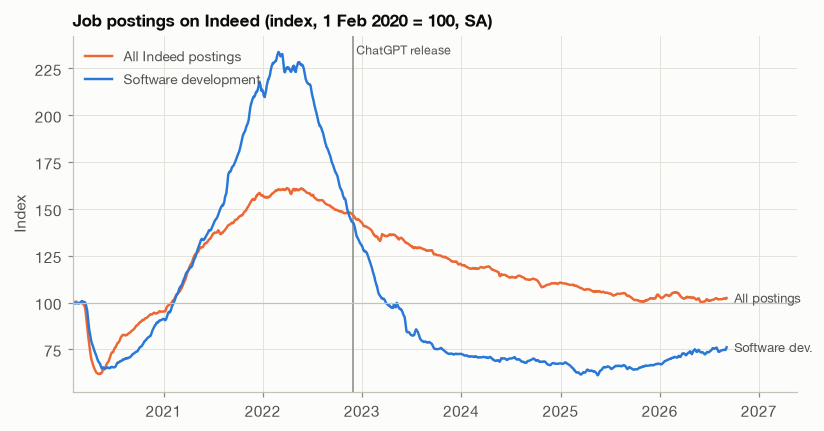

In [3]:
sw, allp = raw["Software Development"].dropna(), raw["All postings"].dropna()
peak_date, peak = sw.idxmax(), sw.max()
at_release = sw.loc[:CHATGPT].iloc[-1]
latest_date, latest = sw.index[-1], sw.iloc[-1]
share_before = (peak - at_release) / (peak - latest)

print(f"Software postings peak:     {peak:6.1f} on {peak_date:%Y-%m-%d}")
print(f"At ChatGPT release:         {at_release:6.1f} on {CHATGPT:%Y-%m-%d}")
print(f"Latest:                     {latest:6.1f} on {latest_date:%Y-%m-%d}")
print(f"All postings latest:        {allp.iloc[-1]:6.1f}")
print(f"Share of the peak-to-latest decline that happened BEFORE the release: {share_before:.0%}")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(allp.index, allp, color=ORANGE, lw=1.6, label="All Indeed postings")
ax.plot(sw.index, sw, color=BLUE, lw=1.6, label="Software development")
label_end(ax, allp.index[-1], allp.iloc[-1], "All postings")
label_end(ax, sw.index[-1], sw.iloc[-1], "Software dev.")
ax.axhline(100, color=BASELINE, lw=0.8)
mark_chatgpt(ax)
ax.set_xlim(sw.index[0], sw.index[-1] + pd.Timedelta(days=260))
ax.set_title("Job postings on Indeed (index, 1 Feb 2020 = 100, SA)")
ax.set_ylabel("Index")
ax.legend(loc="upper left")
save(fig, "02_indeed_software_vs_all");

## 2. Change since the pre-release window, all occupations

In [4]:
counts = raw.resample("MS").count()
monthly = raw.resample("MS").mean().where(counts >= 20)   # drop partial months
last = monthly["All postings"].last_valid_index()
PRE_WIN = slice("2022-09-01", "2022-11-01")
POST_WIN = slice(last - pd.DateOffset(months=2), last)
print(f"Pre window: Sep-Nov 2022; post window: {POST_WIN.start:%b %Y}-{last:%b %Y}")

chg = pd.DataFrame({
    "index_now_vs_feb2020": monthly.loc[POST_WIN].mean(),
    "log_change_since_pre": np.log(monthly.loc[POST_WIN].mean()) - np.log(monthly.loc[PRE_WIN].mean()),
}).dropna()
chg["pct_change_since_pre"] = np.expm1(chg.log_change_since_pre) * 100
chg = chg.sort_values("pct_change_since_pre")
chg["rank_worst"] = np.arange(1, len(chg) + 1)
print(f"{len(chg)} series with data in both windows")
chg.round(1)

Pre window: Sep-Nov 2022; post window: Jun 2026-Aug 2026
42 series with data in both windows


,index_now_vs_feb2020,log_change_since_pre,pct_change_since_pre,rank_worst
Software Development,74.2,-0.8,-53.8,1
Accounting,92.1,-0.8,-53.1,2
Medical Information,89.0,-0.7,-49.8,3
Media & Communications,67.6,-0.7,-49.7,4
Scientific Research & Development,78.2,-0.7,-49.5,5
Childcare,89.3,-0.6,-45.0,6
Human Resources,93.7,-0.6,-44.8,7
Administrative Assistance,94.5,-0.6,-43.4,8
Marketing,75.1,-0.6,-43.0,9
Architecture,89.7,-0.5,-42.3,10


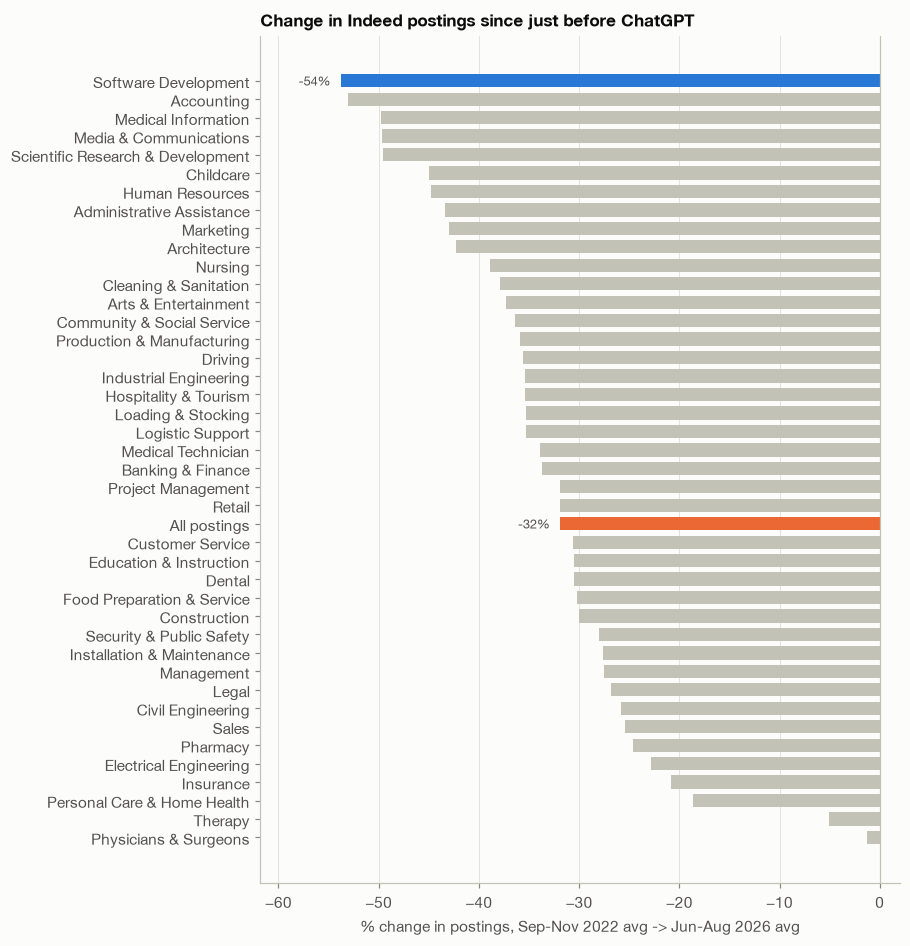

In [5]:
c = chg.iloc[::-1]
colors = [BLUE if o == "Software Development" else ORANGE if o == "All postings" else CONTEXT_GREY for o in c.index]
fig, ax = plt.subplots(figsize=(7.5, 10))
ax.barh(c.index, c.pct_change_since_pre, color=colors, height=0.72)
for i, (o, v) in enumerate(zip(c.index, c.pct_change_since_pre)):
    if o in ("Software Development", "All postings"):
        ax.text(v - 1 if v < 0 else v + 1, i, f"{v:.0f}%", va="center",
                ha="right" if v < 0 else "left", fontsize=8.5, color=INK_2)
ax.axvline(0, color=BASELINE, lw=0.8)
ax.set_xlim(c.pct_change_since_pre.min() - 8, 2)  # room for the value label left of the longest bar
ax.grid(axis="y", visible=False)
ax.set_xlabel(f"% change in postings, Sep-Nov 2022 avg -> {POST_WIN.start:%b}-{last:%b %Y} avg")
ax.set_title("Change in Indeed postings since just before ChatGPT")
save(fig, "02_indeed_change_by_occupation");

## 3. Difference-in-differences with placebo-permutation inference

$\log(\text{index}_{ot}) = \alpha_o + \gamma_t + \beta\,(\text{Software}_o \times \text{Post}_t) + \varepsilon_{ot}$ on monthly data. The sample runs from 2021-01 to the latest full month; "All postings" is excluded because it is an aggregate.

In [6]:
panel = (np.log(monthly.drop(columns="All postings")).loc["2020-02-01":last]
         .stack().rename("log_idx").reset_index())
panel.columns = ["month", "occ", "log_idx"]
OCCS = sorted(panel.occ.unique())

def did(treated, post_start=POST_START, data=None, start="2021-01-01", end=None):
    d = panel if data is None else data
    d = d[(d.month >= start) & ((d.month <= end) if end is not None else True)].dropna(subset=["log_idx"])
    d = d.assign(treat=((d.occ == treated) & (d.month >= post_start)).astype(float))
    return smf.ols("log_idx ~ treat + C(occ) + C(month)", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": pd.factorize(d.occ)[0]})

def permutation(post_start=POST_START, **kw):
    est = {o: did(o, post_start, **kw).params["treat"] for o in OCCS}
    s = pd.Series(est)
    b = s["Software Development"]
    others = s.drop("Software Development")
    return {"beta": b, "pct_effect": np.expm1(b) * 100,
            "rank_most_negative": int((s < b).sum() + 1), "n_units": len(s),
            "perm_p_one_sided": ((others <= b).sum() + 1) / (len(others) + 1),
            "placebo_sd": others.std()}, s

m = did("Software Development")
print(f"Software x Post: beta = {m.params['treat']:.3f}  (cluster SE {m.bse['treat']:.3f}; "
      "unreliable with one treated unit - use permutation below)")

specs = {
    "Main: 2021-01..latest, post = Dec 2022":            dict(start="2021-01-01"),
    "Long pre-period: 2020-02..latest":                  dict(start="2020-02-01"),
    "Post-boom pre-period: 2022-06..latest":             dict(start="2022-06-01"),
    "Placebo in time: pre-data only, fake post = Mar 2022": dict(start="2021-01-01", end="2022-11-01", post_start=pd.Timestamp("2022-03-01")),
    "Placebo in time: pre-data only, fake post = Jun 2022": dict(start="2021-01-01", end="2022-11-01", post_start=pd.Timestamp("2022-06-01")),
}
rows, draws = {}, {}
for name, kw in specs.items():
    rows[name], draws[name] = permutation(**kw)
did_table = pd.DataFrame(rows).T
did_table.round(3)

Software x Post: beta = -0.588  (cluster SE 0.032; unreliable with one treated unit - use permutation below)


,beta,pct_effect,rank_most_negative,n_units,perm_p_one_sided,placebo_sd
"Main: 2021-01..latest, post = Dec 2022",-0.588,-44.467,1.0,47.0,0.021,0.221
Long pre-period: 2020-02..latest,-0.535,-41.422,1.0,47.0,0.021,0.206
Post-boom pre-period: 2022-06..latest,-0.560,-42.883,1.0,47.0,0.021,0.191
"Placebo in time: pre-data only, fake post = Mar 2022",0.057,5.909,33.0,47.0,0.702,0.096
"Placebo in time: pre-data only, fake post = Jun 2022",-0.036,-3.561,16.0,47.0,0.340,0.090


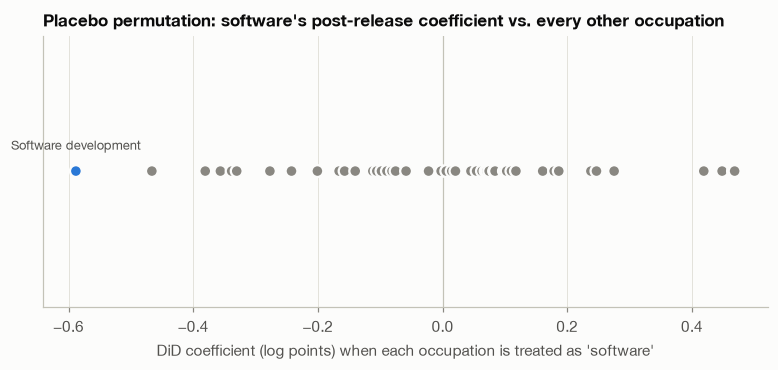

In [7]:
s = draws["Main: 2021-01..latest, post = Dec 2022"].sort_values()
fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.scatter(s.values, np.zeros(len(s)), s=60, color=[BLUE if o == "Software Development" else MUTED for o in s.index],
           edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.annotate("Software development", (s["Software Development"], 0), xytext=(0, 14), textcoords="offset points",
            ha="center", fontsize=8.5, color=INK_2)
ax.set_yticks([]); ax.grid(axis="y", visible=False)
ax.axvline(0, color=BASELINE, lw=0.8)
ax.set_xlabel("DiD coefficient (log points) when each occupation is treated as 'software'")
ax.set_title("Placebo permutation: software's post-release coefficient vs. every other occupation")
save(fig, "02_indeed_did_permutation");

## 4. Quarterly event study (software minus the mean of other occupations, 2022Q3 = 0)

date,2020Q1,2020Q2,2020Q3,2020Q4,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2,2026Q3
software_gap,-0.137,-0.060,-0.264,-0.229,-0.153,-0.136,-0.044,0.086,0.155,0.138,0.0,-0.199,-0.384,-0.524,-0.642,-0.690,-0.680,-0.670,-0.655,-0.654,-0.683,-0.649,-0.649,-0.636,-0.599,-0.503,-0.499
placebo_p05,-0.148,-0.305,-0.261,-0.280,-0.196,-0.217,-0.187,-0.146,-0.122,-0.092,0.0,-0.126,-0.226,-0.279,-0.321,-0.335,-0.327,-0.334,-0.332,-0.340,-0.358,-0.385,-0.382,-0.367,-0.355,-0.306,-0.306
placebo_p95,0.218,0.311,0.354,0.263,0.206,0.235,0.162,0.118,0.126,0.115,0.0,0.099,0.169,0.208,0.257,0.291,0.310,0.359,0.404,0.424,0.424,0.464,0.423,0.427,0.400,0.214,0.282


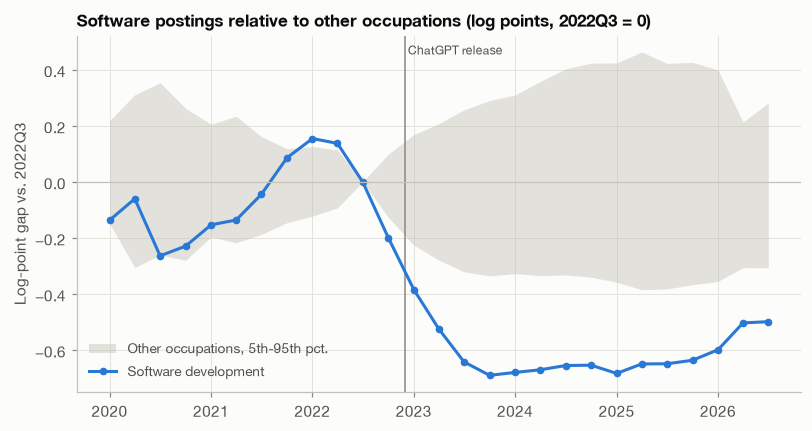

In [8]:
lp = np.log(monthly.drop(columns="All postings")).loc[:last]
q = lp.groupby(lp.index.to_period("Q")).mean()

def rel_gap(occ):
    g = q[occ] - q.drop(columns=occ).mean(axis=1)
    return g - g.loc[pd.Period("2022Q3")]

es = pd.DataFrame({o: rel_gap(o) for o in q.columns})
band = es.drop(columns="Software Development").quantile([0.05, 0.95], axis=1).T
x = q.index.to_timestamp()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.fill_between(x, band[0.05], band[0.95], color=CONTEXT_GREY, alpha=0.45, lw=0,
                label="Other occupations, 5th-95th pct.")
ax.plot(x, es["Software Development"], color=BLUE, marker="o", ms=4, label="Software development")
ax.axhline(0, color=BASELINE, lw=0.8)
mark_chatgpt(ax)
ax.set_title("Software postings relative to other occupations (log points, 2022Q3 = 0)")
ax.set_ylabel("Log-point gap vs. 2022Q3")
ax.legend(loc="lower left")
save(fig, "02_indeed_event_study")

es_out = pd.DataFrame({"software_gap": es["Software Development"], "placebo_p05": band[0.05], "placebo_p95": band[0.95]})
es_out.index = es_out.index.astype(str)
es_out.round(3).T

## 5. Does GPT exposure predict the post-release change in postings?

Indeed categories do not match SOC occupations exactly, so each category is mapped to a small set of representative 2018-SOC codes (**author's crosswalk, listed below**). Exposure is the May 2022 employment-weighted mean of the Eloundou et al. (2024) β score, GPT-4 rated and human rated. This mapping is coarse, so treat the section as descriptive.

In [9]:
CROSSWALK = {
    "Software Development": ["15-1251", "15-1252", "15-1253", "15-1254"],
    "IT Operations & Helpdesk": ["15-1231", "15-1232", "15-1244"],
    "Mathematics": ["15-2011", "15-2021", "15-2031", "15-2041", "15-2051"],
    "Information Design & Documentation": ["27-3042", "15-1255", "27-1024"],
    "Scientific Research & Development": ["19-1042", "19-2031", "19-1029", "19-4021"],
    "Electrical Engineering": ["17-2071", "17-2072"],
    "Civil Engineering": ["17-2051"],
    "Industrial Engineering": ["17-2112"],
    "Architecture": ["17-1011"],
    "Banking & Finance": ["13-2051", "13-2072", "43-3071", "41-3031"],
    "Accounting": ["13-2011", "43-3031"],
    "Insurance": ["41-3021", "13-1031", "13-2053", "43-9041"],
    "Legal": ["23-1011", "23-2011"],
    "Marketing": ["13-1161", "11-2021"],
    "Media & Communications": ["27-3031", "27-3023", "27-3043", "27-3041"],
    "Human Resources": ["13-1071", "11-3121"],
    "Management": ["11-1021"],
    "Project Management": ["13-1082"],
    "Administrative Assistance": ["43-6014", "43-4171", "43-9061"],
    "Customer Service": ["43-4051"],
    "Sales": ["41-4012", "41-3091"],
    "Retail": ["41-2031", "41-2011"],
    "Arts & Entertainment": ["27-2012", "27-2042", "27-1013"],
    "Education & Instruction": ["25-2021", "25-2031", "25-9045"],
    "Nursing": ["29-1141", "29-2061"],
    "Physicians & Surgeons": ["29-1215", "29-1228"],
    "Therapy": ["29-1123", "29-1127", "29-1122"],
    "Pharmacy": ["29-1051", "29-2052"],
    "Dental": ["29-1292", "31-9091", "29-1021"],
    "Medical Technician": ["29-2012", "29-2034", "29-2055"],
    "Medical Information": ["29-9021", "43-6013", "29-2072"],
    "Veterinary": ["29-1131", "29-2056", "31-9096"],
    "Personal Care & Home Health": ["31-1122", "31-1121"],
    "Community & Social Service": ["21-1021", "21-1093", "21-1018"],
    "Childcare": ["39-9011"],
    "Construction": ["47-2061", "47-2031", "47-1011"],
    "Installation & Maintenance": ["49-9071", "49-3023", "49-9021"],
    "Production & Manufacturing": ["51-2090", "51-1011", "51-4041"],
    "Logistic Support": ["43-5071", "43-5061", "13-1081"],
    "Loading & Stocking": ["53-7062", "53-7065"],
    "Driving": ["53-3032", "53-3033", "53-3031"],
    "Cleaning & Sanitation": ["37-2011", "37-2012"],
    "Food Preparation & Service": ["35-2014", "35-3031", "35-3023"],
    "Hospitality & Tourism": ["43-4081", "35-9031"],
    "Security & Public Safety": ["33-9032", "33-3051"],
    "Beauty & Wellness": ["39-5012", "39-5092"],
    "Sports": ["27-2022", "39-9031"],
}
exp6 = load_exposure()
emp22 = load_oews(2022).query("O_GROUP == 'detailed'").set_index("OCC_CODE")["TOT_EMP"]
rows = []
for cat, socs in CROSSWALK.items():
    sub = exp6.reindex(socs).join(emp22.rename("emp")).dropna()
    rows.append({"occ": cat, "soc_matched": f"{len(sub)}/{len(socs)}",
                 "exposure_gpt4": wavg(sub.dv_rating_beta, sub.emp),
                 "exposure_human": wavg(sub.human_rating_beta, sub.emp)})
xw = pd.DataFrame(rows).set_index("occ")
print("Categories with unmatched SOC codes:")
print(xw[xw.soc_matched.str.split("/").map(lambda p: p[0] != p[1])])
xs = chg.drop(index="All postings").join(xw, how="inner")
print(f"{len(xs)} categories in the exposure analysis")

Categories with unmatched SOC codes:
                            soc_matched  exposure_gpt4  exposure_human
occ                                                                   
Education & Instruction             2/3       0.320445        0.323839
Physicians & Surgeons               1/2       0.437500        0.375000
Medical Technician                  2/3       0.274011        0.192968
Personal Care & Home Health         0/2            NaN             NaN
Community & Social Service          2/3       0.323378        0.340260
Production & Manufacturing          2/3       0.346377        0.195044
41 categories in the exposure analysis


In [10]:
import statsmodels.api as sm
res = {}
for label, d in {"All categories": xs, "Excluding software": xs.drop(index="Software Development")}.items():
    for ev in ["exposure_gpt4", "exposure_human"]:
        m = smf.ols(f"pct_change_since_pre ~ {ev}", data=d).fit(cov_type="HC3")
        res[(label, ev)] = {"slope_pp_per_0.1_exposure": m.params[ev] / 10, "se": m.bse[ev] / 10,
                            "p": m.pvalues[ev], "r2": m.rsquared, "n": int(m.nobs)}
exp_reg = pd.DataFrame(res).T
exp_reg.round(3)

slope_pp_per_0.1_exposure     se      p     r2     n
All categories     exposure_gpt4                      -1.591  0.945  0.092  0.077  40.0
                   exposure_human                     -1.295  0.807  0.109  0.040  40.0
Excluding software exposure_gpt4                      -1.106  0.957  0.248  0.035  39.0
                   exposure_human                     -1.112  0.815  0.173  0.032  39.0

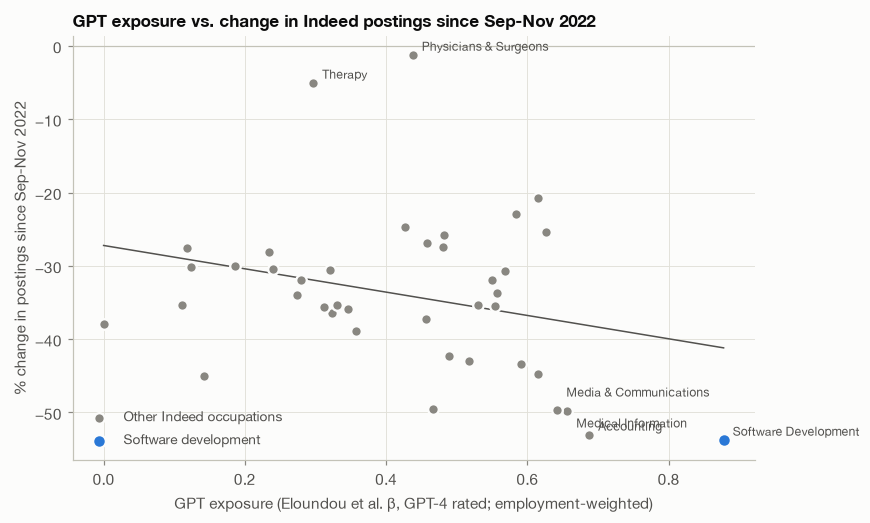

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
others = xs.drop(index="Software Development")
ax.scatter(others.exposure_gpt4, others.pct_change_since_pre, s=48, color=MUTED, edgecolor=SURFACE, lw=1.5, zorder=3,
           label="Other Indeed occupations")
swr = xs.loc["Software Development"]
ax.scatter(swr.exposure_gpt4, swr.pct_change_since_pre, s=70, color=BLUE, edgecolor=SURFACE, lw=1.5, zorder=4,
           label="Software development")
m = smf.ols("pct_change_since_pre ~ exposure_gpt4", data=xs).fit()
gx = np.linspace(xs.exposure_gpt4.min(), xs.exposure_gpt4.max(), 50)
ax.plot(gx, m.params.Intercept + m.params.exposure_gpt4 * gx, color=INK_2, lw=1)
lab = set(xs.pct_change_since_pre.nsmallest(4).index) | set(xs.pct_change_since_pre.nlargest(3).index) | set(xs.exposure_gpt4.nlargest(2).index)
OFFSETS = {"Media & Communications": 9, "Medical Information": -11}  # these two points nearly coincide
for o in lab:
    r = xs.loc[o]
    ax.annotate(o, (r.exposure_gpt4, r.pct_change_since_pre), xytext=(6, OFFSETS.get(o, 3)), textcoords="offset points",
                fontsize=8, color=INK_2)
ax.axhline(0, color=BASELINE, lw=0.8)
ax.set_xlabel("GPT exposure (Eloundou et al. β, GPT-4 rated; employment-weighted)")
ax.set_ylabel("% change in postings since Sep-Nov 2022")
ax.set_title("GPT exposure vs. change in Indeed postings since Sep-Nov 2022")
ax.legend(loc="lower left")
save(fig, "02_indeed_exposure_scatter");

In [12]:
monthly.to_csv(PROCESSED / "indeed_monthly.csv")
xs.to_csv(PROCESSED / "indeed_change_vs_exposure.csv")
did_table.to_csv(PROCESSED / "indeed_did_results.csv")
print("saved processed Indeed tables")

saved processed Indeed tables


## Findings

1. **Software postings collapsed, but most of the fall from peak happened before ChatGPT.**
   - The index (Feb 2020 = 100) peaked at 234 on 28 Feb 2022, fell to 143 by 30 Nov 2022, and stood at 76 on 4 Sep 2026. All postings stood at 102.
   - **58% of the peak-to-latest decline occurred before the release.** That timing matches the unwinding of the 2021–22 boom and the rate hikes that began in March 2022.
2. **Since the release, software fell more than any of the 41 Indeed occupational categories.** Its postings dropped **54%** from Sep–Nov 2022 to Jun–Aug 2026, against 32% for all postings. Next came accounting (−53%), medical information (−50%), media & communications (−50%) and scientific R&D (−50%). Several of these are also highly GPT-exposed white-collar categories.
3. **Difference-in-differences.** After Dec 2022, software postings fell **−0.59 log points (≈ −44%)** relative to other occupations.
   - This is the most negative of all 47 placebo assignments (permutation p = 0.021, the minimum attainable with 47 units).
   - It is stable across pre-period windows (−0.54 to −0.59).
4. **Timing.**
   - Placebo-in-time regressions on pre-release data find no break at March or June 2022 (β = +0.06 and −0.04, ranks 33 and 16 of 47).
   - The quarterly event study shows software already sliding from its 2022Q1 boom high (+0.16) toward the 2022Q3 reference.
   - It left the placebo band in 2022Q4 (−0.20; that quarter is mostly pre-release). It kept falling through 2023 (−0.38 in 2023Q1, trough −0.69 in 2023Q4), stayed flat through 2025, and partly recovered to −0.50 by 2026Q3.
5. **The exposure gradient is weak.** Across 40 categories, 0.1 more GPT exposure goes with a 1.6 pp larger decline (HC3 p = 0.09, R² = 0.08). Excluding software, the slope is −1.1 pp (p = 0.25).

**Interpretation.** Software postings underperformed every other occupation after 2022. But the decline began before generative AI was widely available, and postings carry no seniority information. The pattern fits an AI effect layered on a tech-cycle correction, and it cannot separate the two. It says nothing directly about juniors versus seniors.